Libraries

In [186]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


Edge Detection


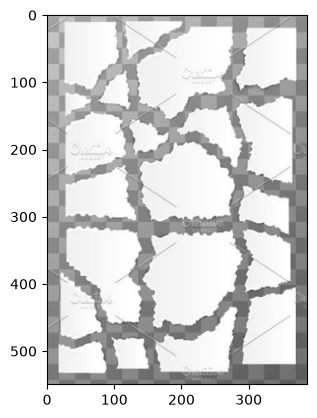

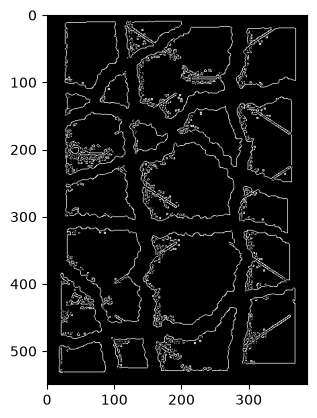

In [187]:
image_path = r'D:\PythonProject1\Intern\Images\img111.png'
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)
_, thresh = cv2.threshold(gray_image, 240, 245, cv2.THRESH_BINARY_INV)
canny = cv2.Canny(thresh,50,150)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(canny, cmap='gray')
plt.show()

Seperate Each Torn Fragment using Contours

In [188]:
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
contour_img = image.copy()
cv2.drawContours(contour_img, valid_contours, -1, (0, 255, 0), 3)


array([[[199, 199, 199],
        [199, 199, 199],
        [199, 199, 199],
        ...,
        [169, 169, 169],
        [166, 166, 166],
        [166, 166, 166]],

       [[205, 205, 205],
        [205, 205, 205],
        [204, 204, 204],
        ...,
        [167, 167, 167],
        [167, 167, 167],
        [168, 168, 168]],

       [[182, 182, 182],
        [181, 181, 181],
        [180, 180, 180],
        ...,
        [151, 151, 151],
        [148, 148, 148],
        [149, 149, 149]],

       ...,

       [[147, 147, 147],
        [147, 147, 147],
        [147, 147, 147],
        ...,
        [111, 111, 111],
        [110, 110, 110],
        [110, 110, 110]],

       [[146, 146, 146],
        [146, 146, 146],
        [146, 146, 146],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       [[146, 146, 146],
        [146, 146, 146],
        [146, 146, 146],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]]

In [189]:
isolated_pieces_list = []  
count=0
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad =0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    rgb_piece = cv2.cvtColor(isolated_piece, cv2.COLOR_BGR2RGB)
    isolated_pieces_list.append(rgb_piece)
    count += 1
    # plt.imshow(rgb_piece)
    # plt.show()

In [190]:
img = isolated_pieces_list[0]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
y, x = np.where(thresh == 255)
highest = np.argmax(x)
peak_x = x[highest]
peak_y = y[highest]
output_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
cv2.circle(output_img, (peak_x, peak_y), 0, (0,0,255), -1)
# plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
# plt.show()
# print(peak_y)
# print(peak_x)

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[234, 234, 234],
        [244, 244, 244],
        [240, 240, 240],
        ...,
        [239, 239, 239],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[238, 238, 238],
        [248, 248, 248],
        [243, 243, 243],
        ...,
        [216, 216, 216],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

Add padding using peak

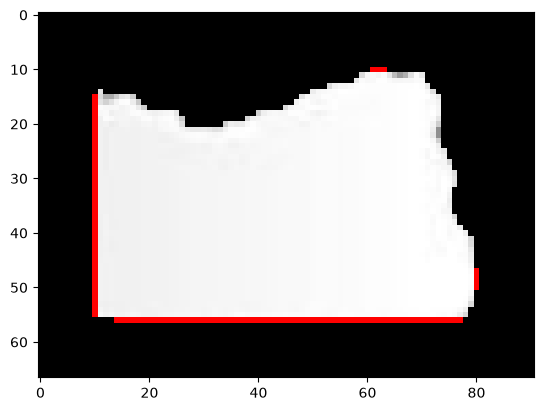

In [191]:
bottom = np.max(y)  
right = np.max(x)  
top= np.min(y) 
left = np.min(x)  
padding_color=[0,0,0]
output= cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
output = cv2.copyMakeBorder(output,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)

bottom += 10
right += 10
top += 10
left += 10
y1 = x[y == (bottom-10)]+10
for peak_y in y1:
    cv2.circle(output, (peak_y, bottom), 0, (0, 0, 255), -1)
    # print(peak_y, bottom)

y2 = y[x == right-10]+10 
for peak_y in y2:
    cv2.circle(output, (right, peak_y), 0, (0, 0, 255), -1) 
    #print(x2,peak_y)

y3 = x[y == top-10]+10 
for peak_y in y3:
    cv2.circle(output, (peak_y, top), 0, (0, 0, 255), -1)
    #print(peak_y, x3)
y4 = y[x == left-10]+10 
for peak_y in y4:
    cv2.circle(output, (left, peak_y), 0, (0, 0, 255), -1)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()



Top :    TORN (avg: 7.14px)
Bottom : STRAIGHT (avg: 0.82px)
Left :   TORN (avg: 13.33px)
Right :  TORN (avg: 3.37px)


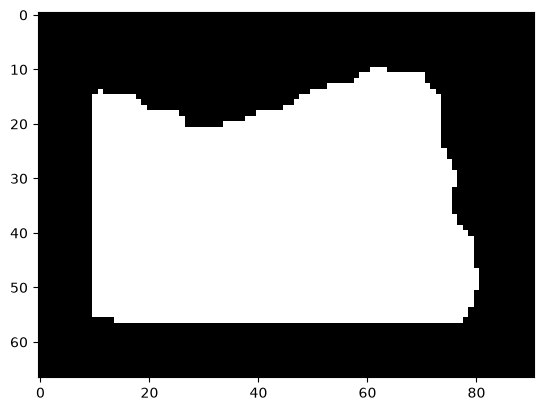

Top :    TORN (avg: 9.43px)
Bottom : TORN (avg: 11.15px)
Left :   TORN (avg: 2.97px)
Right :  TORN (avg: 8.11px)


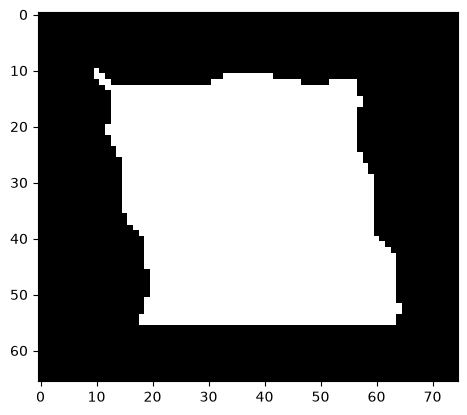

Top :    TORN (avg: 17.00px)
Bottom : TORN (avg: 18.86px)
Left :   TORN (avg: 44.68px)
Right :  TORN (avg: 4.24px)


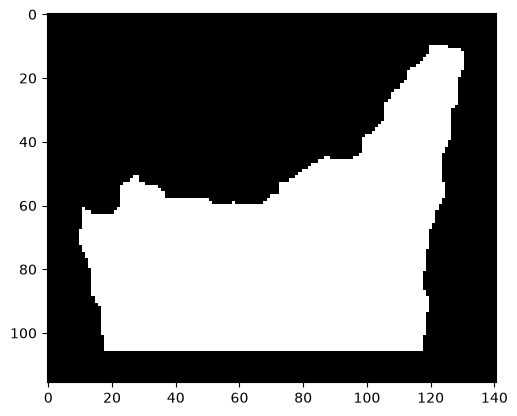

Top :    TORN (avg: 21.46px)
Bottom : TORN (avg: 11.52px)
Left :   TORN (avg: 17.20px)
Right :  STRAIGHT (avg: 0.21px)


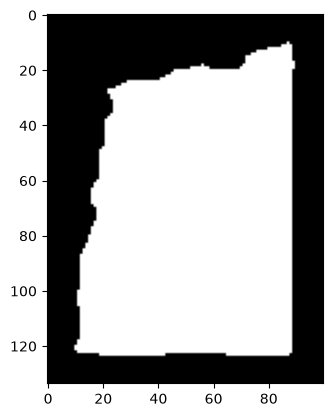

Top :    TORN (avg: 22.30px)
Bottom : TORN (avg: 11.58px)
Left :   TORN (avg: 3.12px)
Right :  TORN (avg: 16.87px)


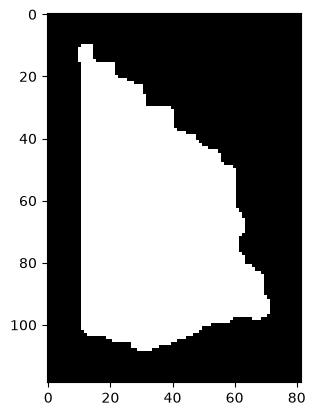

Top :    TORN (avg: 16.95px)
Bottom : TORN (avg: 27.00px)
Left :   TORN (avg: 14.85px)
Right :  TORN (avg: 25.29px)


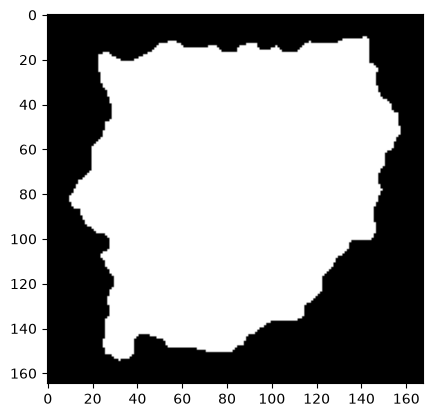

Top :    TORN (avg: 6.32px)
Bottom : TORN (avg: 12.71px)
Left :   TORN (avg: 4.15px)
Right :  TORN (avg: 18.31px)


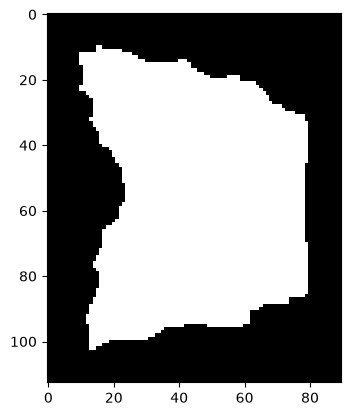

Top :    TORN (avg: 5.59px)
Bottom : TORN (avg: 33.99px)
Left :   TORN (avg: 24.47px)
Right :  TORN (avg: 13.59px)


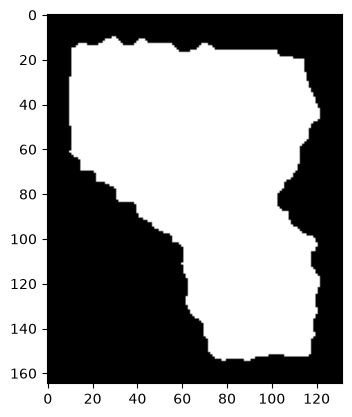

Top :    TORN (avg: 7.96px)
Bottom : TORN (avg: 6.73px)
Left :   TORN (avg: 22.69px)
Right :  TORN (avg: 18.30px)


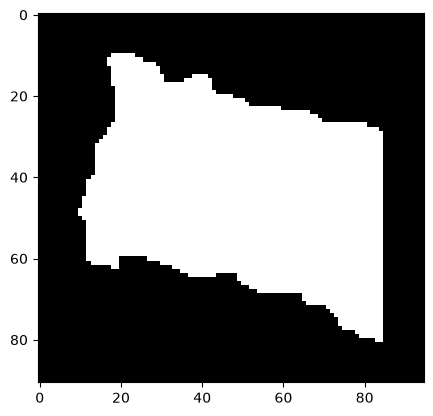

Top :    TORN (avg: 17.15px)
Bottom : TORN (avg: 2.24px)
Left :   TORN (avg: 32.05px)
Right :  TORN (avg: 5.39px)


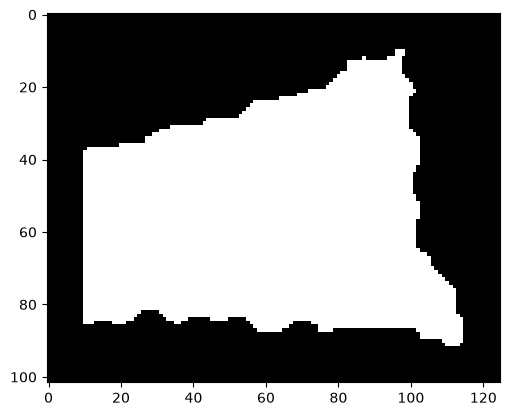

Top :    TORN (avg: 15.43px)
Bottom : TORN (avg: 12.17px)
Left :   TORN (avg: 17.79px)
Right :  TORN (avg: 20.34px)


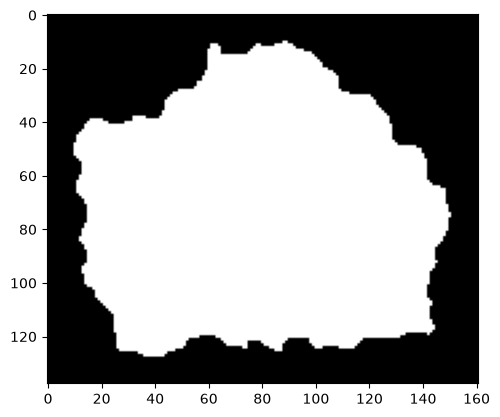

Top :    TORN (avg: 8.28px)
Bottom : TORN (avg: 10.32px)
Left :   TORN (avg: 2.69px)
Right :  TORN (avg: 15.38px)


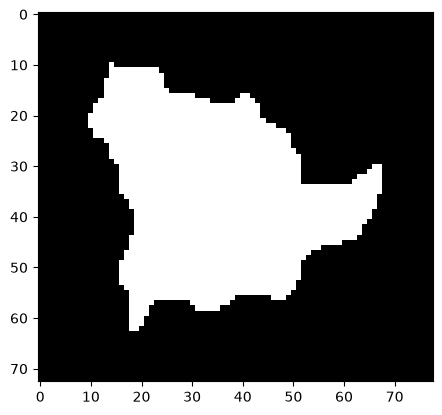

Top :    TORN (avg: 9.66px)
Bottom : TORN (avg: 8.92px)
Left :   TORN (avg: 10.85px)
Right :  TORN (avg: 22.37px)


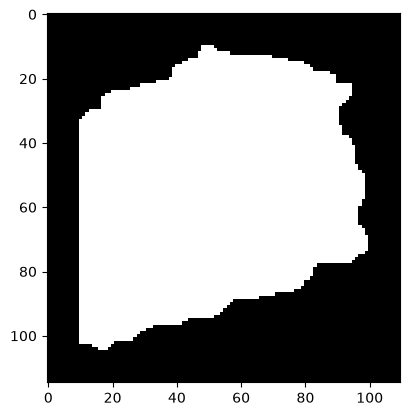

Top :    TORN (avg: 15.44px)
Bottom : TORN (avg: 17.43px)
Left :   TORN (avg: 28.33px)
Right :  TORN (avg: 7.45px)


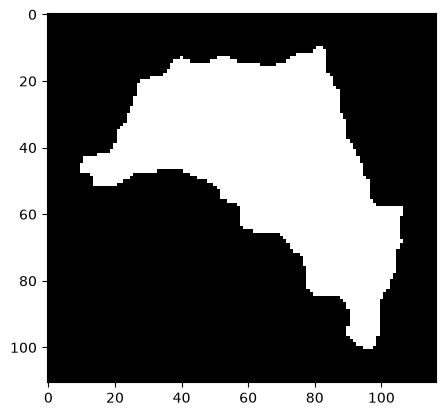

Top :    TORN (avg: 5.04px)
Bottom : TORN (avg: 31.06px)
Left :   TORN (avg: 17.91px)
Right :  TORN (avg: 2.10px)


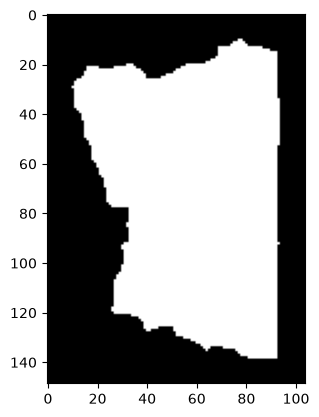

Top :    TORN (avg: 3.29px)
Bottom : TORN (avg: 6.07px)
Left :   STRAIGHT (avg: 0.46px)
Right :  TORN (avg: 12.24px)


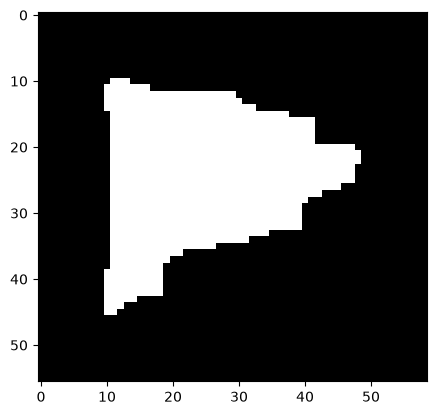

Top :    TORN (avg: 13.81px)
Bottom : TORN (avg: 2.85px)
Left :   TORN (avg: 12.59px)
Right :  TORN (avg: 1.79px)


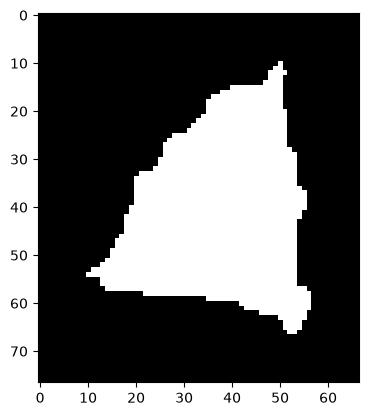

Top :    TORN (avg: 22.48px)
Bottom : TORN (avg: 4.60px)
Left :   TORN (avg: 5.18px)
Right :  TORN (avg: 15.94px)


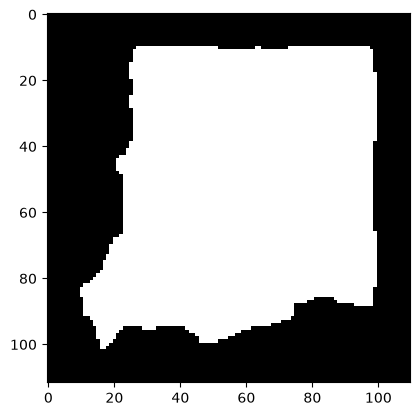

Top :    TORN (avg: 18.65px)
Bottom : TORN (avg: 21.42px)
Left :   TORN (avg: 25.09px)
Right :  TORN (avg: 30.41px)


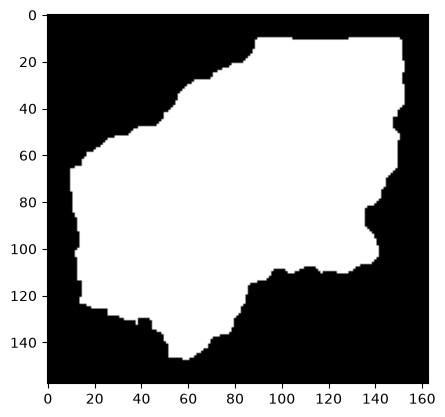

Top :    STRAIGHT (avg: 0.87px)
Bottom : TORN (avg: 15.25px)
Left :   TORN (avg: 1.79px)
Right :  TORN (avg: 24.83px)


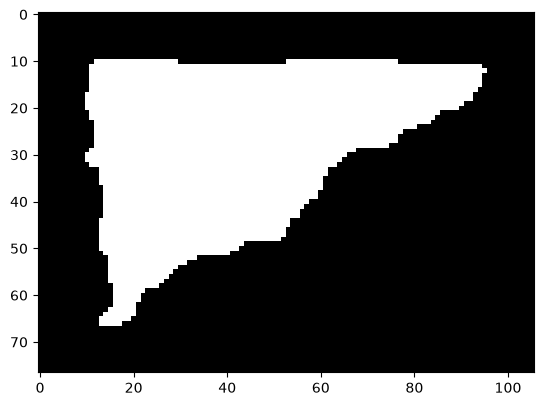

Top :    TORN (avg: 6.31px)
Bottom : TORN (avg: 26.32px)
Left :   TORN (avg: 7.37px)
Right :  TORN (avg: 20.39px)


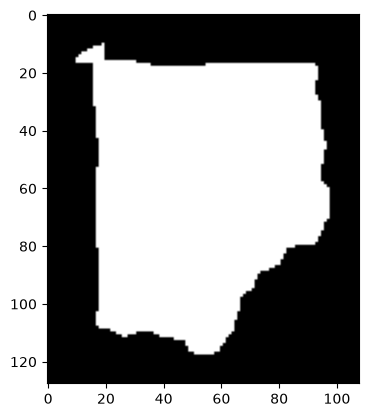

In [192]:
for i in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(i, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    points = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(points)

    tol = 1.5 

    top_deviations = []
    bottom_deviations = []

    for col in range(x, x + w):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            actual_top_edge = white_pixels[0]
            top_deviations.append(int(actual_top_edge - y))
                    
            actual_bottom_edge = white_pixels[-1]
            absolute_bottom_peak = y + h
            bottom_deviations.append(int(absolute_bottom_peak - actual_bottom_edge))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0

    top1_is_torn = std_top > tol
    bottom1_is_torn = std_bottom > tol

    print(f"Top :    {'TORN' if top1_is_torn else 'STRAIGHT'} (avg: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom1_is_torn else 'STRAIGHT'} (avg: {std_bottom:.2f}px)")


    left_avg = []
    right_avg = []

    for row in range(y, y + h):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            actual_left_edge = white_pixels[0]
            left_avg.append(int(actual_left_edge - x))
                    
            actual_right_edge = white_pixels[-1]
            absolute_right_peak = x + w
            right_avg.append(int(absolute_right_peak - actual_right_edge))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0

    left1_is_torn = std_left > tol
    right1_is_torn = std_right > tol

    print(f"Left :   {'TORN' if left1_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right1_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    plt.imshow(thresh, cmap='gray')
    plt.show()

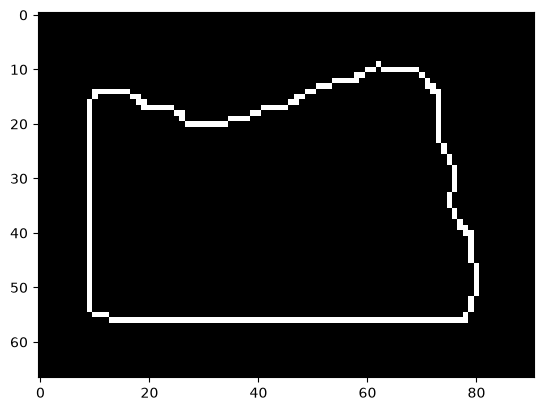

[(9, 16), (10, 14), (11, 14), (12, 14), (13, 14), (14, 14), (15, 14), (16, 14), (17, 15), (18, 15), (19, 16), (20, 17), (21, 17), (22, 17), (23, 17), (24, 17), (25, 18), (26, 18), (27, 20), (28, 20), (29, 20), (30, 20), (31, 20), (32, 20), (33, 20), (34, 20), (35, 19), (36, 19), (37, 19), (38, 19), (39, 18), (40, 18), (41, 17), (42, 17), (43, 17), (44, 17), (45, 17), (46, 16), (47, 15), (48, 15), (49, 14), (50, 14), (51, 13), (52, 13), (53, 13), (54, 12), (55, 12), (56, 12), (57, 12), (58, 11), (59, 11), (60, 10), (61, 10), (62, 9), (63, 10), (64, 10), (65, 10), (66, 10), (67, 10), (68, 10), (69, 10), (70, 11), (71, 12), (72, 13), (73, 14), (74, 24), (75, 26), (76, 28), (77, 38), (78, 39), (79, 40), (80, 46)]
[(9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (4

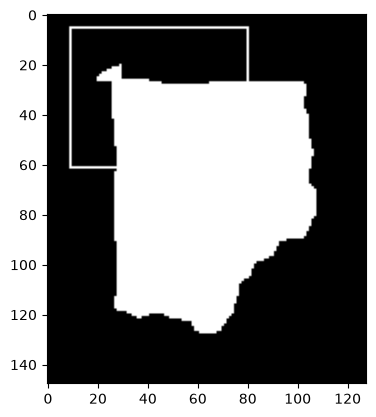

In [193]:
img=isolated_pieces_list[0]
img = cv2.copyMakeBorder(img,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
_, img = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
a1=cv2.Canny(img,150,150)
y_arr, x_arr = np.where(a1 == 255)

left = np.min(x_arr)
right = np.max(x_arr)
b11= []
for col_x in range(left, right + 1):
    pixels_in_col = y_arr[x_arr == col_x]
    
    if len(pixels_in_col) > 0:
        top_y = np.min(pixels_in_col)
        
        b11.append((int(col_x), int(top_y)))
plt.imshow(cv2.cvtColor(a1, cv2.COLOR_BGR2RGB))
plt.show()
a2 = cv2.copyMakeBorder(thresh,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
g1= 5
b1=(left , top - g1)
b2=(right , bottom + g1)

cv2.rectangle(a2, b1, b2, (255, 255, 255), 1)
y_arr, x_arr = np.where(a2 == 255)

left = np.min(x_arr)
right = np.max(x_arr)
b22 = []
for col_x in range(left, right + 1):
    pixels_in_col = y_arr[x_arr == col_x]
    
    if len(pixels_in_col) > 0:
        top_y = np.min(pixels_in_col)
        
        b22.append((int(col_x), int(top_y)))
distances = [int(y11) - int(y22) for (_, y11), (_, y22) in zip(b11, b22)]

print(b11)
print(b22)
print(distances)
plt.imshow(cv2.cvtColor(a2, cv2.COLOR_BGR2RGB))
plt.show()

Top :    TORN (avg: 7.14px)
Bottom : STRAIGHT (avg: 0.82px)
Left :   TORN (avg: 13.33px)
Right :  TORN (avg: 3.37px)


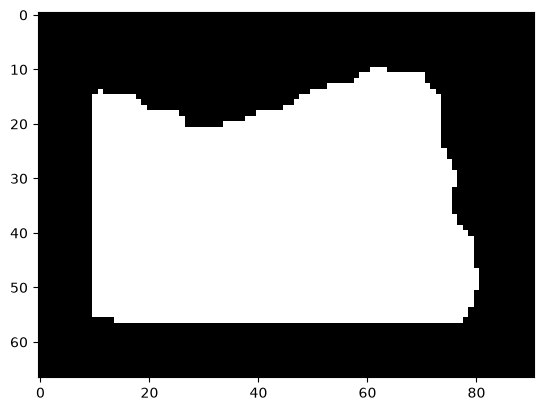

Top :    TORN (avg: 9.43px)
Bottom : TORN (avg: 11.15px)
Left :   TORN (avg: 2.97px)
Right :  TORN (avg: 8.11px)


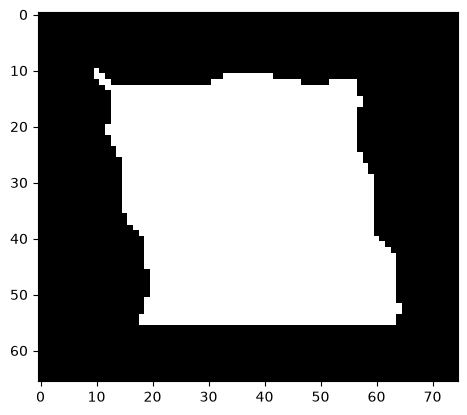

Top :    TORN (avg: 17.00px)
Bottom : TORN (avg: 18.86px)
Left :   TORN (avg: 44.68px)
Right :  TORN (avg: 4.24px)


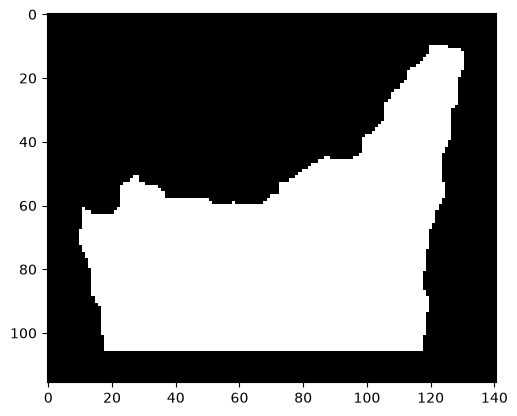

Top :    TORN (avg: 21.46px)
Bottom : TORN (avg: 11.52px)
Left :   TORN (avg: 17.20px)
Right :  STRAIGHT (avg: 0.21px)


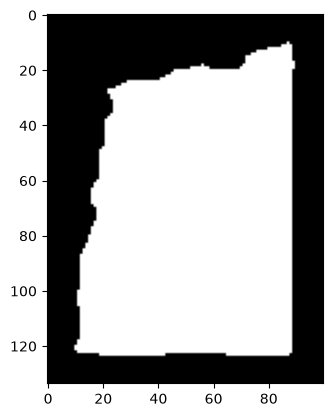

Top :    TORN (avg: 22.30px)
Bottom : TORN (avg: 11.58px)
Left :   TORN (avg: 3.12px)
Right :  TORN (avg: 16.87px)


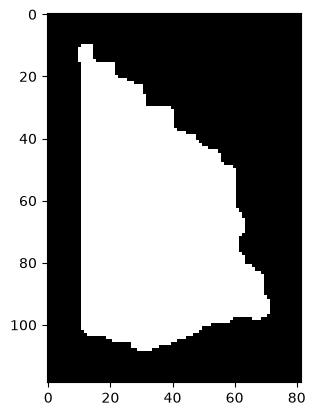

Top :    TORN (avg: 16.95px)
Bottom : TORN (avg: 27.00px)
Left :   TORN (avg: 14.85px)
Right :  TORN (avg: 25.29px)


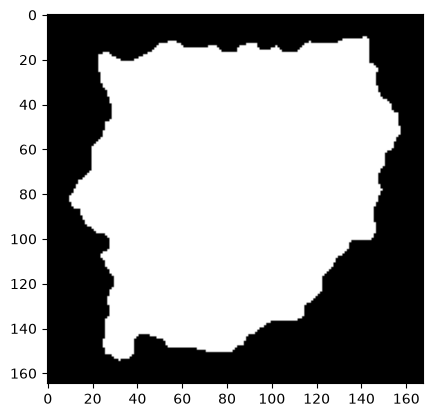

Top :    TORN (avg: 6.32px)
Bottom : TORN (avg: 12.71px)
Left :   TORN (avg: 4.15px)
Right :  TORN (avg: 18.31px)


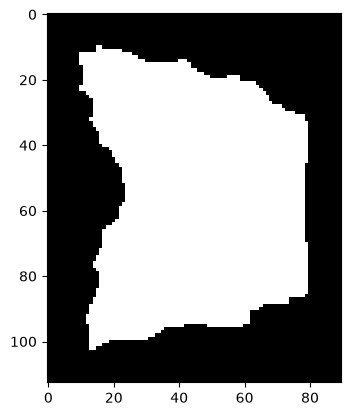

Top :    TORN (avg: 5.59px)
Bottom : TORN (avg: 33.99px)
Left :   TORN (avg: 24.47px)
Right :  TORN (avg: 13.59px)


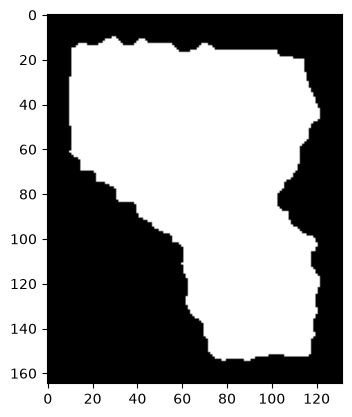

Top :    TORN (avg: 7.96px)
Bottom : TORN (avg: 6.73px)
Left :   TORN (avg: 22.69px)
Right :  TORN (avg: 18.30px)


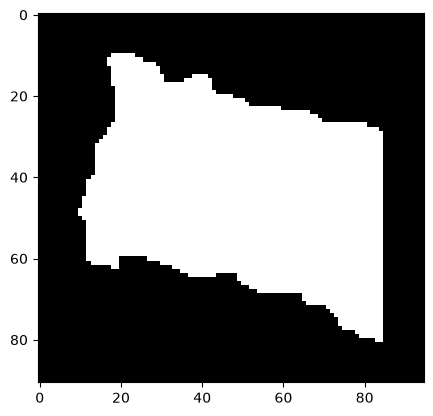

Top :    TORN (avg: 17.15px)
Bottom : TORN (avg: 2.24px)
Left :   TORN (avg: 32.05px)
Right :  TORN (avg: 5.39px)


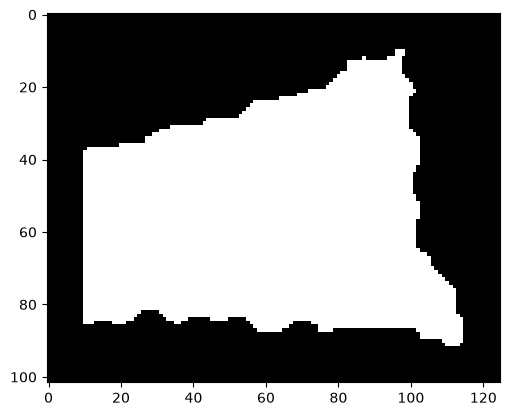

Top :    TORN (avg: 15.43px)
Bottom : TORN (avg: 12.17px)
Left :   TORN (avg: 17.79px)
Right :  TORN (avg: 20.34px)


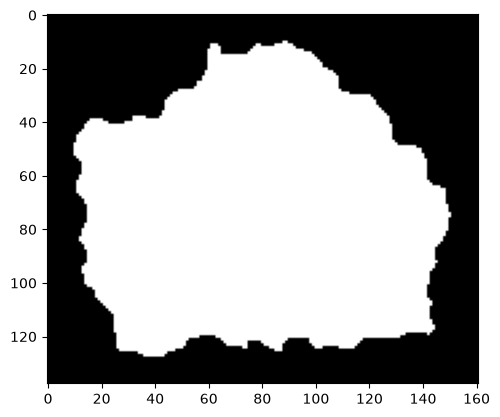

Top :    TORN (avg: 8.28px)
Bottom : TORN (avg: 10.32px)
Left :   TORN (avg: 2.69px)
Right :  TORN (avg: 15.38px)


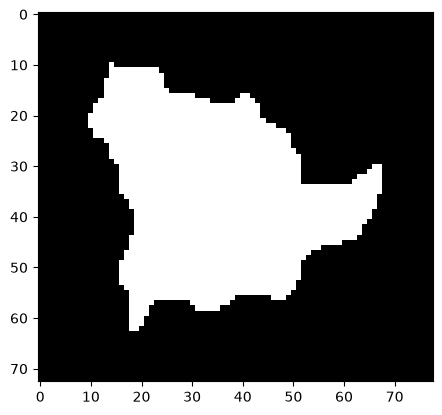

Top :    TORN (avg: 9.66px)
Bottom : TORN (avg: 8.92px)
Left :   TORN (avg: 10.85px)
Right :  TORN (avg: 22.37px)


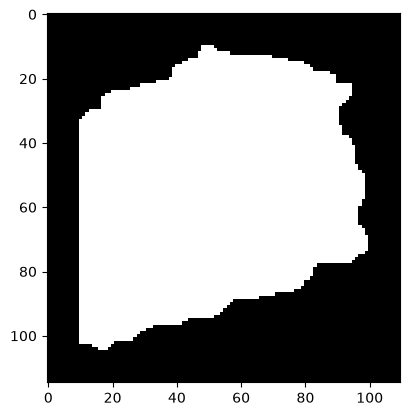

Top :    TORN (avg: 15.44px)
Bottom : TORN (avg: 17.43px)
Left :   TORN (avg: 28.33px)
Right :  TORN (avg: 7.45px)


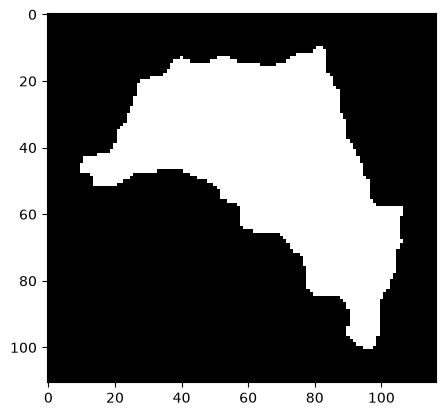

Top :    TORN (avg: 5.04px)
Bottom : TORN (avg: 31.06px)
Left :   TORN (avg: 17.91px)
Right :  TORN (avg: 2.10px)


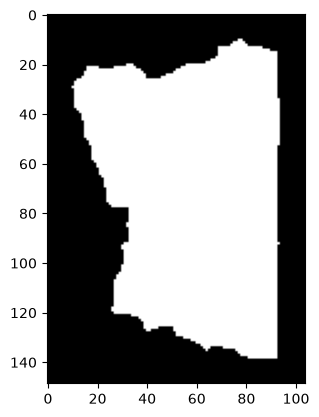

Top :    TORN (avg: 3.29px)
Bottom : TORN (avg: 6.07px)
Left :   STRAIGHT (avg: 0.46px)
Right :  TORN (avg: 12.24px)


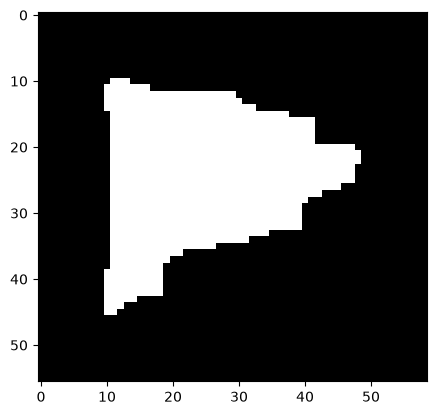

Top :    TORN (avg: 13.81px)
Bottom : TORN (avg: 2.85px)
Left :   TORN (avg: 12.59px)
Right :  TORN (avg: 1.79px)


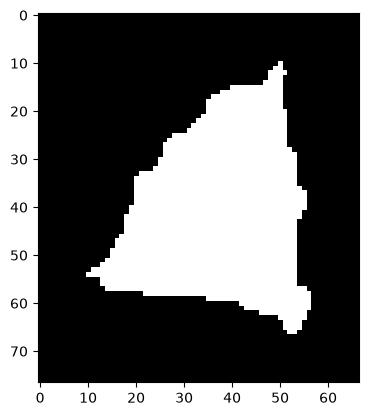

Top :    TORN (avg: 22.48px)
Bottom : TORN (avg: 4.60px)
Left :   TORN (avg: 5.18px)
Right :  TORN (avg: 15.94px)


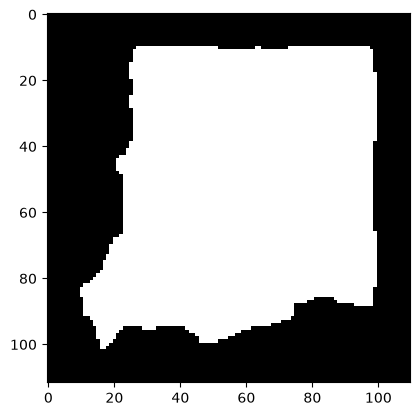

Top :    TORN (avg: 18.65px)
Bottom : TORN (avg: 21.42px)
Left :   TORN (avg: 25.09px)
Right :  TORN (avg: 30.41px)


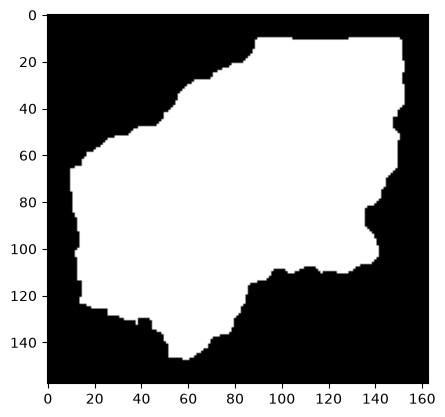

Top :    STRAIGHT (avg: 0.87px)
Bottom : TORN (avg: 15.25px)
Left :   TORN (avg: 1.79px)
Right :  TORN (avg: 24.83px)


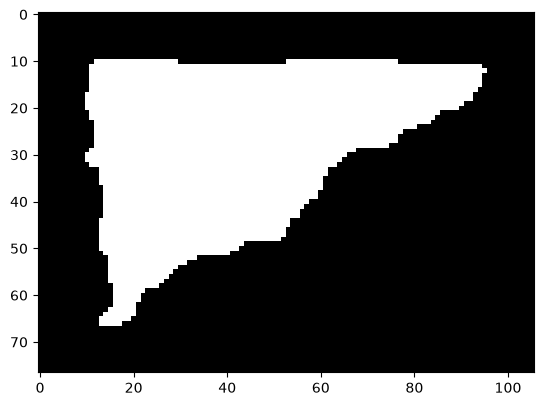

Top :    TORN (avg: 6.31px)
Bottom : TORN (avg: 26.32px)
Left :   TORN (avg: 7.37px)
Right :  TORN (avg: 20.39px)


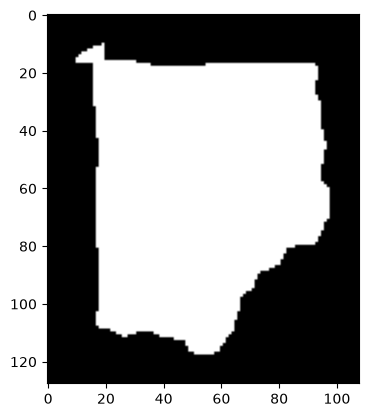

In [194]:
for i in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(i, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    points = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(points)

    tol = 1.5 

    top_deviations = []
    bottom_deviations = []

    for col in range(x, x + w):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            actual_top_edge = white_pixels[0]
            top_deviations.append(int(actual_top_edge - y))
                    
            actual_bottom_edge = white_pixels[-1]
            absolute_bottom_peak = y + h
            bottom_deviations.append(int(absolute_bottom_peak - actual_bottom_edge))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0

    top1_is_torn = std_top > tol
    bottom1_is_torn = std_bottom > tol

    print(f"Top :    {'TORN' if top1_is_torn else 'STRAIGHT'} (avg: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom1_is_torn else 'STRAIGHT'} (avg: {std_bottom:.2f}px)")


    left_avg = []
    right_avg = []

    for row in range(y, y + h):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            actual_left_edge = white_pixels[0]
            left_avg.append(int(actual_left_edge - x))
                    
            actual_right_edge = white_pixels[-1]
            absolute_right_peak = x + w
            right_avg.append(int(absolute_right_peak - actual_right_edge))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0

    left1_is_torn = std_left > tol
    right1_is_torn = std_right > tol

    print(f"Left :   {'TORN' if left1_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right1_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    plt.imshow(thresh, cmap='gray')
    plt.show()

Top :    TORN (variance: 7.14px)
Bottom : STRAIGHT (variance: 0.82px)
Left :   TORN (avg: 13.33px)
Right :  TORN (avg: 3.37px)
TOP Distances[9, 9, 9, 9, 9, 9, 9, 10, 10, 11, 12, 12, 12, 12, 12, 13, 13, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 13, 13, 12, 12, 12, 12, 12, 11, 10, 10, 9, 9, 8, 8, 8, 7, 7, 7, 7, 6, 6, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 6, 7, 8, 9, 19, 21, 23, 33, 34, 35, 41]
LEFT Distances [55, 53, 49, 46, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 8]
RIGHT Distances[16, 15, 14, 13, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 10, 10, 9, 9, 9, 9, 9, 10, 10, 10, 9, 9, 8, 7, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 6, 6, 6, 7, 7]


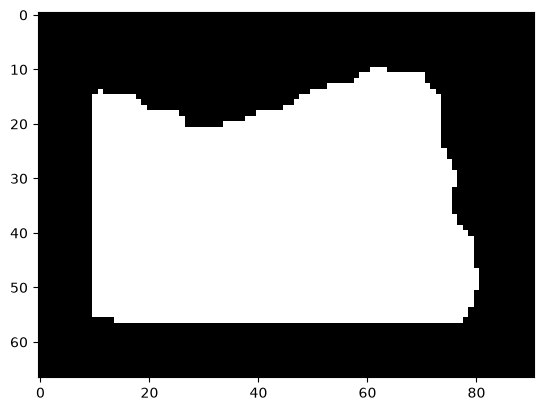

Top :    TORN (variance: 9.43px)
Bottom : TORN (variance: 11.15px)
Left :   TORN (avg: 2.97px)
Right :  TORN (avg: 8.11px)
TOP Distances[5, 5, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 7, 9, 21, 23, 34, 35, 36, 37, 46]
BOTTOM Distances[48, 47, 38, 36, 26, 24, 22, 21, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6]
LEFT Distances [4, 4, 5, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 11, 11, 12, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13]
RIGHT Distances[29, 14, 13, 13, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 12, 12, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 8, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 6]


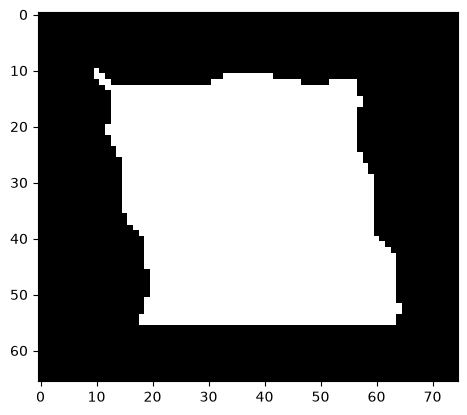

Top :    TORN (variance: 17.00px)
Bottom : TORN (variance: 18.86px)
Left :   TORN (avg: 44.68px)
Right :  TORN (avg: 4.24px)
TOP Distances[56, 56, 56, 57, 57, 57, 57, 57, 57, 57, 57, 56, 50, 48, 48, 47, 46, 46, 46, 47, 48, 48, 48, 48, 49, 49, 50, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 53, 53, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 53, 52, 52, 51, 49, 48, 47, 47, 47, 46, 45, 44, 44, 43, 42, 42, 41, 41, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 39, 35, 33, 33, 32, 31, 30, 29, 24, 22, 21, 19, 19, 18, 16, 14, 12, 12, 11, 10, 9, 8, 6, 5, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6]
BOTTOM Distances[37, 35, 32, 23, 21, 19, 11, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 9, 16, 42, 44, 48, 50, 52, 68, 70, 80, 81, 

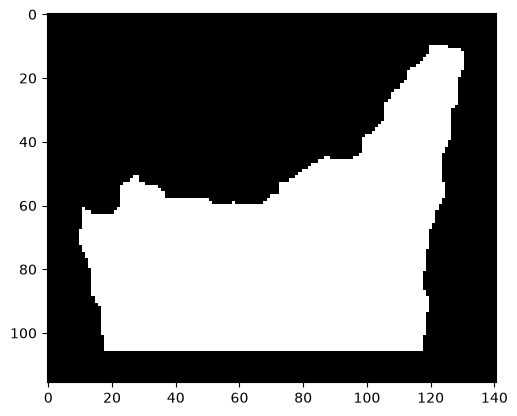

Top :    TORN (variance: 21.46px)
Bottom : TORN (variance: 11.52px)
Left :   TORN (avg: 17.20px)
Right :  STRAIGHT (avg: 0.21px)
TOP Distances[96, 83, 81, 79, 76, 59, 57, 55, 45, 43, 34, 32, 22, 21, 21, 21, 20, 20, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 16, 15, 15, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 11, 10, 9, 9, 8, 8, 7, 7, 7, 7, 6, 6, 6, 6, 6, 5, 5, 5, 11]
BOTTOM Distances[6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 108]
LEFT Distances [81, 76, 72, 70, 68, 67, 66, 66, 48, 42, 40, 39, 37, 25, 23, 21, 18, 17, 17, 17, 18, 18, 18, 18, 18, 18, 17, 16, 16, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 11, 11, 10, 10, 10, 10, 11, 11, 12, 12, 12, 12, 12, 12, 11, 11, 10, 10

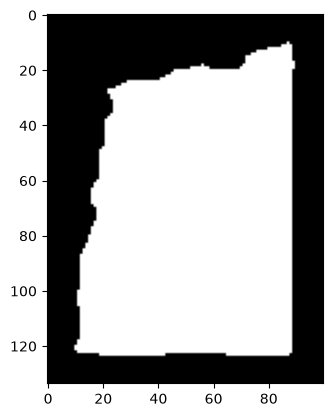

Top :    TORN (variance: 22.30px)
Bottom : TORN (variance: 11.58px)
Left :   TORN (avg: 3.12px)
Right :  TORN (avg: 16.87px)
TOP Distances[5, 5, 4, 4, 5, 9, 10, 10, 10, 10, 10, 11, 14, 15, 15, 16, 16, 17, 17, 17, 18, 20, 24, 24, 24, 24, 24, 24, 24, 25, 25, 31, 32, 32, 33, 33, 33, 34, 35, 36, 37, 38, 38, 38, 39, 39, 42, 43, 43, 44, 44, 57, 58, 60, 75, 76, 76, 77, 78, 78, 85, 86]
BOTTOM Distances[13, 11, 10, 10, 10, 10, 10, 10, 9, 9, 8, 8, 8, 8, 8, 8, 7, 6, 5, 5, 5, 5, 5, 5, 5, 6, 6, 7, 7, 7, 7, 8, 8, 9, 9, 9, 10, 10, 11, 11, 12, 13, 13, 13, 14, 14, 14, 14, 14, 14, 15, 16, 16, 16, 16, 15, 15, 15, 15, 15, 16, 16]
LEFT Distances [5, 5, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 7, 13, 15, 21, 22, 23]
RIGHT Distances[62, 62, 62, 62, 61, 56, 55, 55, 55, 54, 52, 50, 

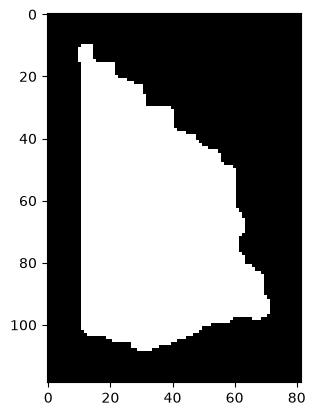

Top :    TORN (variance: 16.95px)
Bottom : TORN (variance: 27.00px)
Left :   TORN (avg: 14.85px)
Right :  TORN (avg: 25.29px)
TOP Distances[75, 74, 72, 70, 69, 68, 67, 66, 65, 55, 53, 52, 14, 13, 12, 12, 11, 12, 12, 13, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 13, 13, 12, 12, 11, 10, 9, 8, 8, 7, 7, 7, 7, 6, 6, 7, 7, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 9, 9, 10, 11, 11, 11, 11, 11, 11, 11, 9, 9, 8, 8, 8, 7, 7, 7, 8, 9, 10, 10, 10, 10, 10, 10, 9, 9, 9, 10, 11, 11, 11, 11, 11, 11, 11, 10, 9, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 16, 17, 17, 18, 29, 31, 32, 33, 33, 34, 37, 38, 39, 44]
BOTTOM Distances[75, 73, 73, 73, 71, 69, 67, 65, 65, 64, 63, 62, 62, 62, 12, 9, 8, 8, 7, 6, 6, 5, 5, 5, 6, 6, 6, 6, 7, 14, 15, 16, 17, 17, 17, 16, 16, 16, 15, 15, 15, 14, 13, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 11, 12, 12, 13, 15, 16, 17, 17, 17, 18, 19, 20, 20, 

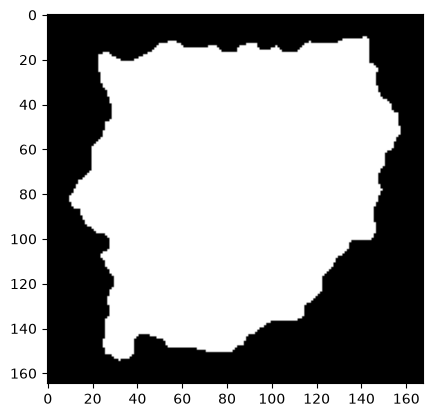

Top :    TORN (variance: 6.32px)
Bottom : TORN (variance: 12.71px)
Left :   TORN (avg: 4.15px)
Right :  TORN (avg: 18.31px)
TOP Distances[7, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 7, 7, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 9, 9, 11, 12, 12, 13, 13, 14, 14, 14, 14, 14, 14, 14, 13, 13, 14, 15, 15, 15, 15, 16, 16, 17, 18, 19, 21, 22, 22, 23, 23, 24, 24, 25, 25, 25, 26, 27]
BOTTOM Distances[84, 14, 6, 5, 5, 5, 6, 6, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 10, 10, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 16, 17, 17, 17, 18, 19, 19, 19, 19, 19, 19, 19, 20, 21, 21, 21, 21, 21]
LEFT Distances [10, 6, 5, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 10, 10, 10, 11, 11, 13, 14, 15, 15, 16, 16, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 17, 17, 16, 16, 16, 15, 14, 12, 12, 11, 11, 11, 11, 11, 11, 10, 10, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 9, 9, 9, 8, 8, 7, 7, 7, 6, 7, 7, 7, 7, 7, 7, 7, 7, 8]


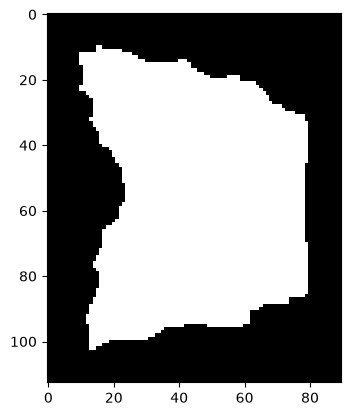

Top :    TORN (variance: 5.59px)
Bottom : TORN (variance: 33.99px)
Left :   TORN (avg: 24.47px)
Right :  TORN (avg: 13.59px)
TOP Distances[11, 10, 9, 8, 8, 7, 7, 8, 8, 8, 8, 8, 8, 8, 7, 6, 6, 5, 5, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 7, 6, 6, 5, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 9, 10, 11, 11, 11, 11, 11, 11, 10, 10, 9, 8, 8, 7, 8, 8, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 12, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 15, 20, 24, 27, 29, 31, 34, 36]
BOTTOM Distances[97, 96, 96, 95, 91, 90, 90, 90, 90, 90, 89, 86, 85, 85, 85, 84, 84, 83, 83, 82, 78, 76, 76, 76, 76, 76, 76, 76, 75, 72, 70, 69, 68, 68, 67, 67, 66, 64, 64, 63, 63, 62, 62, 62, 61, 59, 58, 58, 57, 56, 45, 31, 29, 27, 25, 24, 24, 23, 22, 17, 15, 10, 8, 7, 6, 6, 6, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 14, 15, 25, 37]
LEFT Distances [22, 20, 10, 8, 7, 6, 5, 5, 5, 5,

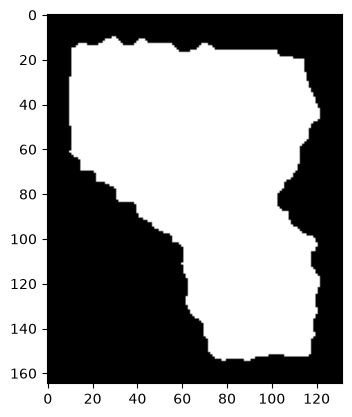

Top :    TORN (variance: 7.96px)
Bottom : TORN (variance: 6.73px)
Left :   TORN (avg: 22.69px)
Right :  TORN (avg: 18.30px)
TOP Distances[41, 37, 35, 28, 26, 25, 24, 5, 5, 4, 4, 4, 4, 5, 5, 6, 6, 6, 7, 7, 9, 11, 11, 11, 11, 11, 11, 10, 10, 9, 9, 10, 10, 13, 14, 14, 14, 15, 15, 15, 16, 16, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 19, 19, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 23, 23]
BOTTOM Distances[35, 26, 24, 24, 24, 24, 24, 23, 23, 23, 25, 26, 26, 26, 26, 26, 25, 25, 25, 24, 24, 24, 23, 23, 22, 22, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 21, 19, 19, 18, 18, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 14, 14, 14, 14, 14, 13, 12, 11, 10, 8, 8, 8, 7, 6, 6, 6, 6, 5, 5, 5]
LEFT Distances [12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 11, 10, 9, 9, 8, 8, 8, 8, 8, 8, 8, 7, 7, 6, 6, 6, 6, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 12, 29, 31, 44, 44, 46, 48, 59, 60, 60, 65, 66, 67, 68, 69, 69, 72, 73, 77]
RIG

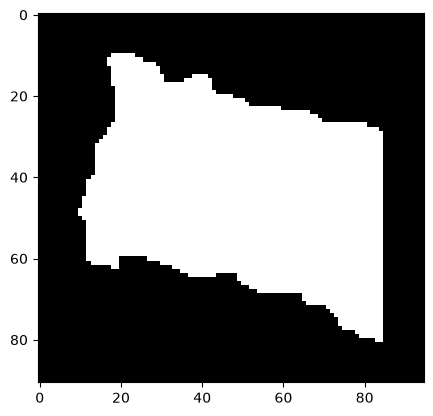

Top :    TORN (variance: 17.15px)
Bottom : TORN (variance: 2.24px)
Left :   TORN (avg: 32.05px)
Right :  TORN (avg: 5.39px)
TOP Distances[32, 32, 31, 31, 31, 31, 31, 31, 31, 31, 31, 30, 30, 30, 30, 30, 30, 29, 28, 28, 27, 27, 26, 26, 26, 25, 25, 25, 25, 25, 25, 25, 25, 24, 24, 23, 23, 23, 23, 23, 23, 23, 23, 22, 21, 20, 19, 19, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 16, 16, 16, 15, 15, 15, 15, 14, 13, 12, 11, 11, 9, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 5, 4, 5, 12, 13, 15, 28, 60, 61, 61, 64, 65, 66, 67, 68, 69, 70, 77, 78]
BOTTOM Distances[11, 11, 11, 11, 12, 12, 12, 11, 11, 11, 11, 11, 11, 12, 12, 13, 14, 15, 15, 15, 14, 13, 12, 12, 11, 11, 11, 11, 12, 12, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 12, 11, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 11, 12, 12, 12, 11, 11, 10, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 8, 7, 7, 7, 7, 7, 6, 5, 5, 5, 5, 5, 5]
LEFT Distances [91, 90, 79, 78, 77, 77, 75, 74, 73

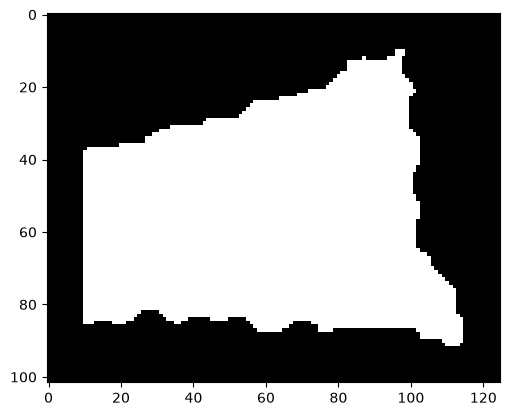

Top :    TORN (variance: 15.43px)
Bottom : TORN (variance: 12.17px)
Left :   TORN (avg: 17.79px)
Right :  TORN (avg: 20.34px)
TOP Distances[41, 39, 38, 37, 35, 34, 34, 33, 33, 33, 34, 34, 35, 35, 35, 35, 35, 35, 35, 35, 34, 34, 33, 32, 32, 32, 33, 33, 33, 33, 33, 33, 32, 28, 26, 25, 24, 24, 23, 23, 22, 22, 22, 22, 22, 21, 20, 19, 17, 9, 7, 6, 5, 6, 6, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 10, 11, 12, 14, 15, 15, 16, 16, 17, 22, 23, 23, 24, 24, 24, 24, 24, 24, 24, 24, 25, 25, 26, 28, 29, 30, 31, 32, 35, 41, 42, 43, 43, 43, 43, 43, 43, 44, 44, 45, 46, 48, 56, 57, 58, 58, 59, 59, 60, 65, 68]
BOTTOM Distances[67, 65, 37, 33, 31, 31, 30, 28, 26, 25, 24, 23, 22, 21, 15, 9, 7, 7, 7, 7, 7, 7, 7, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 7, 7, 7, 8, 8, 8, 10, 11, 12, 12, 12, 12, 13, 13, 13, 13, 12, 12, 11, 10, 9, 9, 9, 9, 9, 9, 8, 8, 8, 10, 11, 11, 11, 10, 9, 9, 8, 8, 7, 7, 7, 7, 9, 10, 11, 12, 12, 12, 12, 12, 12, 11, 9, 8, 8, 8, 8

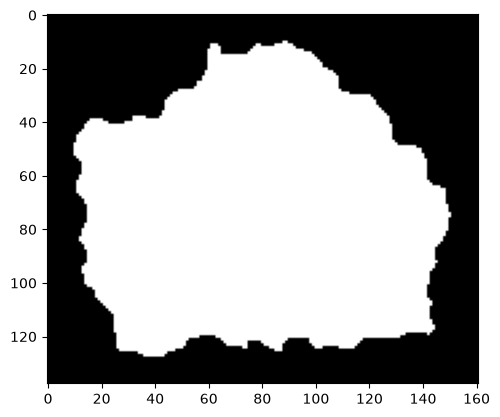

Top :    TORN (variance: 8.28px)
Bottom : TORN (variance: 10.32px)
Left :   TORN (avg: 2.69px)
Right :  TORN (avg: 15.38px)
TOP Distances[14, 12, 9, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 9, 10, 10, 10, 10, 11, 11, 11, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 12, 15, 16, 17, 17, 18, 18, 21, 22, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 27, 27, 26, 25, 25, 25]
BOTTOM Distances[44, 43, 42, 40, 38, 15, 13, 6, 5, 5, 5, 7, 9, 10, 11, 11, 11, 11, 11, 10, 9, 9, 9, 9, 9, 9, 9, 10, 10, 11, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 12, 14, 18, 19, 20, 21, 21, 22, 22, 22, 22, 23, 23, 23, 25, 26, 28, 31]
LEFT Distances [8, 8, 8, 8, 7, 7, 7, 6, 6, 5, 5, 4, 5, 5, 6, 7, 8, 8, 9, 9, 10, 10, 10, 10, 10, 11, 11, 12, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 11, 11, 10, 10, 10, 11, 11, 12, 12, 12, 12, 12, 12, 12, 13]
RIGHT Distances[50, 48, 48, 48, 47, 43, 30, 29, 29, 29, 28, 27, 25, 23, 23, 23, 22, 21, 21, 21, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 7, 7, 8, 9, 9, 12, 16, 18, 19, 20, 21, 21, 21, 21, 22, 22, 23, 34, 36, 51,

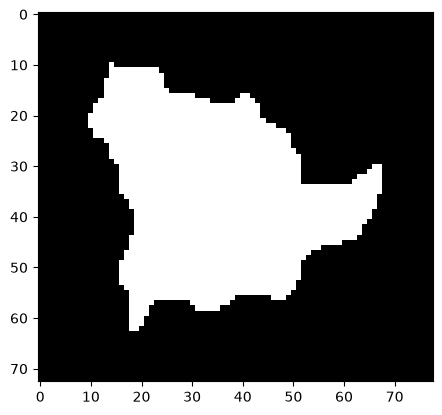

Top :    TORN (variance: 9.66px)
Bottom : TORN (variance: 8.92px)
Left :   TORN (avg: 10.85px)
Right :  TORN (avg: 22.37px)
TOP Distances[27, 26, 25, 25, 24, 24, 22, 20, 20, 19, 19, 18, 18, 18, 18, 18, 18, 17, 17, 17, 16, 16, 16, 16, 16, 15, 15, 15, 13, 11, 11, 10, 10, 9, 9, 8, 8, 6, 5, 4, 4, 5, 5, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 10, 10, 11, 11, 12, 12, 12, 12, 13, 13, 14, 16, 16, 16, 16, 17, 35, 41, 43, 44, 63]
BOTTOM Distances[7, 7, 7, 6, 6, 5, 5, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 8, 9, 10, 11, 11, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 17, 18, 19, 20, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 24, 24, 26, 27, 27, 30, 31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 34, 35, 35]
LEFT Distances [43, 42, 42, 40, 38, 36, 34, 34, 33, 33, 30, 25, 22, 16, 14, 12, 12, 11, 11, 9, 7, 6, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4

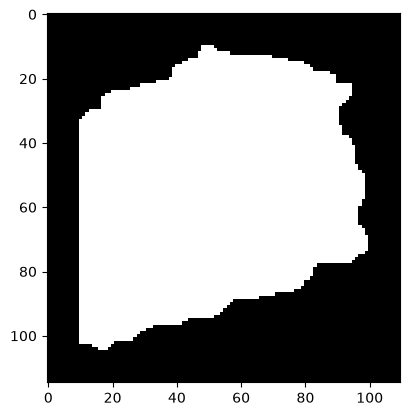

Top :    TORN (variance: 15.44px)
Bottom : TORN (variance: 17.43px)
Left :   TORN (avg: 28.33px)
Right :  TORN (avg: 7.45px)
TOP Distances[39, 38, 37, 37, 37, 37, 36, 36, 36, 35, 31, 29, 28, 26, 24, 21, 17, 15, 15, 14, 14, 14, 13, 13, 13, 12, 11, 9, 9, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 7, 7, 8, 8, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 9, 9, 8, 8, 7, 7, 6, 6, 6, 6, 5, 5, 5, 5, 12, 13, 16, 17, 24, 26, 32, 33, 35, 37, 39, 43, 44, 50, 51, 52, 52, 52, 52, 52, 52, 52, 53]
BOTTOM Distances[58, 58, 57, 55, 54, 54, 54, 54, 54, 54, 54, 54, 55, 55, 56, 56, 57, 58, 58, 58, 58, 58, 58, 58, 59, 59, 59, 59, 59, 59, 58, 58, 57, 57, 56, 56, 56, 55, 55, 54, 53, 51, 50, 49, 49, 49, 48, 43, 41, 41, 41, 40, 40, 40, 40, 40, 40, 40, 40, 39, 38, 37, 36, 34, 34, 33, 31, 24, 22, 21, 21, 21, 21, 21, 21, 21, 21, 20, 19, 10, 8, 7, 6, 6, 5, 5, 5, 5, 5, 8, 19, 21, 22, 25, 27, 34, 36]
LEFT Distances [75, 71, 47, 34, 32, 32, 31, 30, 27, 24, 22, 22, 21, 21, 21, 21, 20, 20, 20, 19, 19, 18, 18, 17, 16, 16

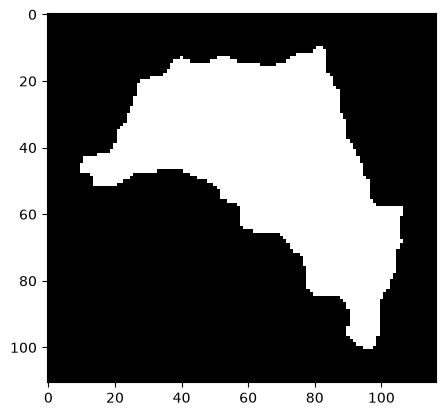

Top :    TORN (variance: 5.04px)
Bottom : TORN (variance: 31.06px)
Left :   TORN (avg: 17.91px)
Right :  TORN (avg: 2.10px)
TOP Distances[23, 21, 21, 20, 19, 17, 16, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 14, 15, 15, 16, 17, 17, 18, 20, 20, 20, 20, 20, 20, 20, 19, 19, 18, 18, 17, 17, 16, 16, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 12, 9, 8, 7, 7, 7, 7, 6, 6, 5, 5, 5, 5, 6, 7, 7, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 28]
BOTTOM Distances[107, 105, 104, 102, 95, 93, 92, 86, 84, 83, 80, 78, 75, 69, 67, 66, 23, 23, 23, 23, 23, 23, 23, 22, 22, 22, 21, 20, 18, 16, 16, 16, 16, 17, 17, 17, 18, 18, 18, 18, 17, 15, 14, 14, 13, 13, 13, 12, 12, 11, 11, 10, 9, 8, 8, 8, 9, 10, 10, 10, 9, 9, 9, 9, 9, 8, 7, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 50]
LEFT Distances [71, 69, 65, 64, 63, 63, 63, 62, 60, 28, 12, 11, 10, 10, 9, 8, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 7, 8, 8, 9, 9, 9, 9, 9, 9, 9, 10, 10, 11, 12, 12, 12, 12, 12, 12, 13, 13, 14, 15, 15, 15, 16, 16, 17, 17

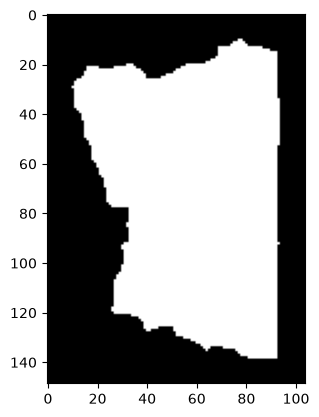

Top :    TORN (variance: 3.29px)
Bottom : TORN (variance: 6.07px)
Left :   STRAIGHT (avg: 0.46px)
Right :  TORN (avg: 12.24px)
TOP Distances[5, 5, 4, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 8, 9, 9, 9, 9, 9, 10, 10, 10, 10, 11, 14, 14, 14, 14, 14, 15, 15]
BOTTOM Distances[5, 5, 5, 6, 7, 7, 8, 8, 8, 12, 13, 14, 14, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 17, 17, 17, 18, 18, 18, 18, 21, 22, 23, 23, 24, 24, 24, 25, 27]
RIGHT Distances[38, 25, 23, 22, 17, 13, 12, 12, 12, 7, 5, 5, 5, 5, 6, 6, 7, 10, 12, 13, 14, 14, 14, 18, 21, 26, 31, 33, 34, 35, 35, 35, 35, 38, 40, 41]


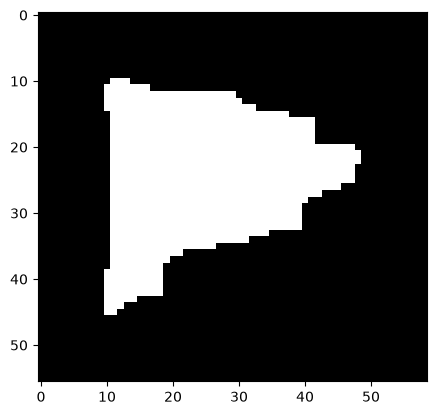

Top :    TORN (variance: 13.81px)
Bottom : TORN (variance: 2.85px)
Left :   TORN (avg: 12.59px)
Right :  TORN (avg: 1.79px)
TOP Distances[48, 48, 47, 46, 45, 43, 41, 38, 36, 30, 28, 28, 27, 27, 26, 23, 21, 20, 20, 19, 19, 18, 17, 16, 14, 12, 12, 11, 11, 10, 10, 9, 9, 9, 9, 9, 9, 8, 6, 5, 5, 6, 22, 23, 30, 31, 52]
BOTTOM Distances[17, 18, 16, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 11, 10, 10, 10, 9, 9, 9, 9, 8, 7, 5, 5, 5, 5, 7, 9]
LEFT Distances [44, 43, 43, 42, 36, 34, 32, 30, 30, 29, 29, 28, 27, 26, 24, 22, 21, 21, 20, 20, 20, 19, 17, 15, 15, 14, 14, 14, 14, 14, 14, 13, 13, 12, 12, 12, 11, 11, 10, 10, 9, 8, 7, 5, 5, 7, 8, 8, 16, 29, 36, 37, 40, 44, 45, 46, 46]
RIGHT Distances[11, 10, 10, 10, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 9, 8, 8, 8, 8, 8, 8, 8, 7, 6, 6, 6, 6, 6, 6, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 5, 5, 5, 5, 5, 5, 6, 6, 7, 7]


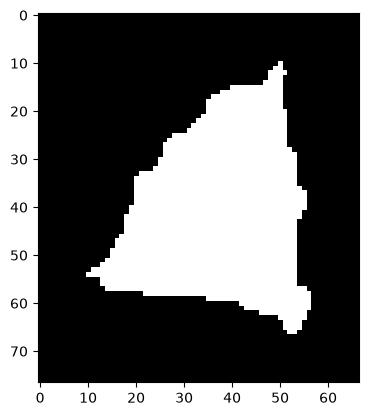

Top :    TORN (variance: 22.48px)
Bottom : TORN (variance: 4.60px)
Left :   TORN (avg: 5.18px)
Right :  TORN (avg: 15.94px)
TOP Distances[77, 77, 76, 75, 74, 73, 71, 69, 66, 64, 40, 38, 38, 37, 11, 7, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 12]
BOTTOM Distances[16, 15, 14, 13, 9, 6, 5, 5, 5, 6, 7, 9, 10, 11, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 11, 10, 10, 9, 8, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 11, 11, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14, 18, 19, 19, 19, 19, 20, 20, 21, 21, 21, 21, 20, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 23]
LEFT Distances [21, 21, 20, 20, 20, 20, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 19, 19, 18, 16, 16, 15, 15, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 1

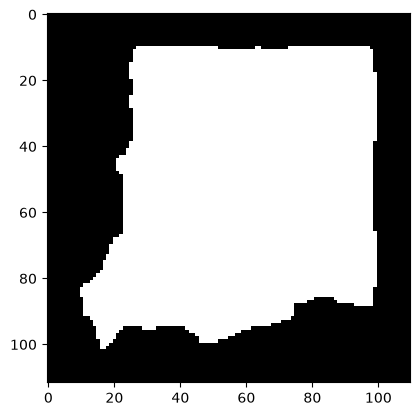

Top :    TORN (variance: 18.65px)
Bottom : TORN (variance: 21.42px)
Left :   TORN (avg: 25.09px)
Right :  TORN (avg: 30.41px)
TOP Distances[61, 60, 60, 59, 58, 56, 55, 54, 53, 53, 52, 52, 51, 50, 49, 48, 48, 47, 47, 47, 46, 46, 46, 46, 46, 45, 44, 44, 43, 43, 42, 42, 42, 42, 42, 42, 42, 41, 40, 38, 37, 36, 35, 34, 33, 30, 28, 27, 26, 25, 25, 24, 23, 23, 22, 22, 22, 22, 22, 22, 21, 20, 19, 19, 18, 18, 17, 17, 16, 16, 15, 15, 15, 15, 14, 13, 12, 11, 7, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 14]
BOTTOM Distances[69, 50, 40, 30, 29, 29, 28, 28, 27, 27, 27, 27, 27, 27, 27, 25, 24, 24, 24, 24, 23, 23, 22, 22, 22, 22, 22, 20, 104, 20, 23, 23, 23, 22, 19, 18, 17, 17, 16, 14, 12, 7, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 6, 6, 7, 8, 8, 9, 10, 11, 13, 14, 15, 15, 15, 16, 16, 16, 16, 18, 22, 23, 24, 27, 28, 32, 36, 37, 38, 38, 38, 39, 39, 39, 39, 40, 42, 43,

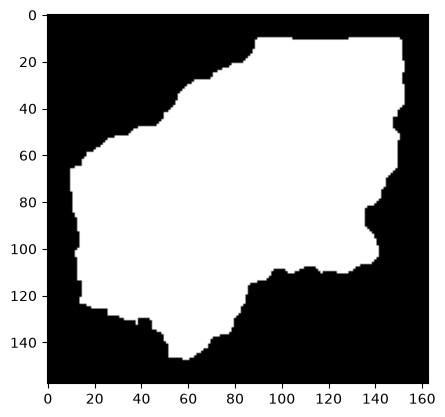

Top :    STRAIGHT (variance: 0.87px)
Bottom : TORN (variance: 15.25px)
Left :   TORN (avg: 1.79px)
Right :  TORN (avg: 24.83px)
BOTTOM Distances[39, 39, 22, 5, 5, 5, 5, 5, 5, 6, 6, 9, 11, 12, 13, 13, 13, 14, 15, 16, 17, 18, 18, 19, 19, 20, 20, 20, 20, 20, 20, 20, 21, 21, 22, 23, 23, 23, 23, 23, 23, 23, 23, 25, 27, 28, 29, 30, 31, 32, 33, 36, 38, 39, 39, 40, 41, 42, 42, 43, 43, 43, 43, 43, 43, 43, 44, 45, 46, 47, 47, 47, 48, 48, 48, 49, 50, 51, 51, 51, 51, 52, 53, 54, 55, 58]
LEFT Distances [6, 6, 5, 5, 5, 5, 5, 5, 4, 4, 5, 5, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 8, 8, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 9, 8, 8, 8]
RIGHT Distances[7, 5, 5, 5, 6, 6, 6, 7, 8, 9, 10, 14, 15, 16, 19, 22, 23, 24, 25, 32, 34, 35, 36, 38, 39, 39, 40, 40, 40, 41, 42, 43, 44, 45, 46, 47, 47, 48, 48, 56, 57, 59, 66, 68, 70, 71, 72, 73, 74, 77, 78, 79, 79, 80, 80, 80, 82]


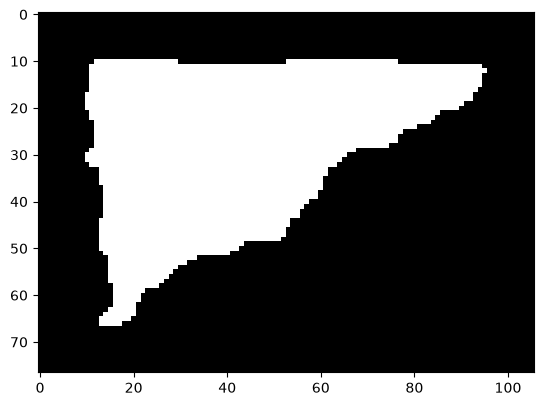

Top :    TORN (variance: 6.31px)
Bottom : TORN (variance: 26.32px)
Left :   TORN (avg: 7.37px)
Right :  TORN (avg: 20.39px)
TOP Distances[9, 8, 8, 7, 7, 6, 6, 5, 5, 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 24, 34, 38, 54]
BOTTOM Distances[106, 106, 106, 106, 106, 92, 16, 14, 14, 14, 14, 13, 13, 12, 12, 11, 11, 11, 11, 12, 12, 12, 13, 13, 13, 13, 12, 12, 11, 11, 11, 11, 11, 10, 10, 10, 10, 9, 7, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 7, 8, 10, 11, 12, 16, 19, 24, 25, 26, 27, 27, 30, 32, 33, 34, 34, 34, 35, 35, 36, 37, 39, 41, 42, 42, 42, 43, 43, 43, 43, 43, 43, 43, 45, 47, 50, 51]
LEFT Distances [12, 10, 8, 6, 5, 5, 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12

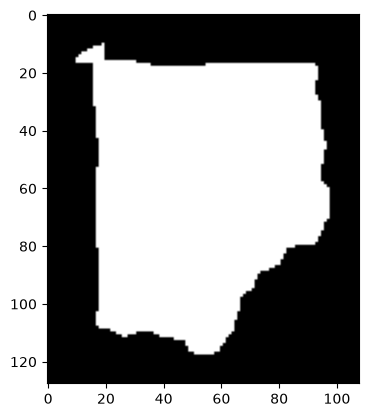

In [195]:
image_path = r'D:\PythonProject1\Intern\Images\img111.png'
image = cv2.imread(image_path)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)

_, thresh_init = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh_init, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

isolated_pieces_list = []  
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    isolated_pieces_list.append(isolated_piece)

for  current_piece in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        print(f"TOP Distances{distances_top}")

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        print(f"BOTTOM Distances{distances_bottom}")

    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        print(f"LEFT Distances {distances_left}")

    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        print(f"RIGHT Distances{distances_right}")

    

    plt.imshow(thresh, cmap='gray')
    plt.show()


In [196]:
def rotate_contour(contour, edge_mask, wOverlay, hOverlay, rotation):    
    hw = 2* max(wOverlay, hOverlay)
    temp = np.zeros((hw,hw), np.uint8)
    #contour = contour + max(wOverlay, hOverlay)
    #temp = draw_contour(temp, contour, 255, 2)
    temp = edge_mask.copy()
    #cv2.imshow('temp', cv2.resize(temp, (456,456)))
    rows,cols = temp.shape
    M = cv2.getRotationMatrix2D((cols/2,rows/2),rotation,1)
    dst = cv2.warpAffine(temp,M,(cols,rows))
    _, thresh = cv2.threshold(dst, 123, 255, cv2.THRESH_BINARY)
    contours, _  = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    return contours[0]
